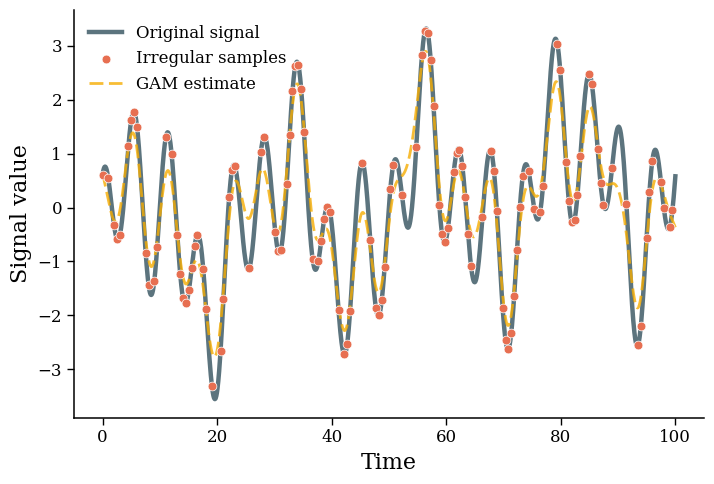

In [88]:
import numpy as np
import matplotlib.pyplot as plt
from pygam import LinearGAM, s

# =========================================================
# STYLE (paper-like)
# =========================================================

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 12,
    "axes.linewidth": 1.1,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.width": 1,
    "ytick.major.width": 1,
})

# =========================================================
# GENERATE ORIGINAL CURVE
# =========================================================

np.random.seed(42)

x_true = np.linspace(0, 100, 2000)

# complex fluctuating signal
y_true = (
    1.2 * np.sin(x_true / 4)
    + 0.7 * np.sin(x_true / 1.7)
    + 1.35 * np.cos(x_true / 0.9)
    + 0.015 * (x_true - 50)
)

# =========================================================
# NON-EQUIDISTANT SAMPLES
# =========================================================

# irregular sampling
x_sample = np.sort(
    np.random.choice(
        np.linspace(0, 100, 200),
        size=120,
        replace=False
    )
)

# interpolate original signal + small noise
y_sample = np.interp(x_sample, x_true, y_true)
y_sample += np.random.normal(0, 0, len(y_sample))

# =========================================================
# GAM FIT
# =========================================================

gam = LinearGAM(
    s(0, n_splines=len(y_sample), lam=0.8)
).fit(x_sample[:, None], y_sample)

y_gam = gam.predict(x_true)

# =========================================================
# COLORS
# =========================================================

color_true = "#1b4965"
color_points = "#ca6702"
color_gam = "#2a9d8f"

color_true = "#1b4965"     # azul profundo
color_points = "#b56576"   # dusty rose
color_gam = "#6d597a"      # muted purple

color_true = "#264653"     # dark teal
color_points = "#e76f51"   # coral
color_gam = "#a1a94a" 
color_gam ="#dbb314"  
color_gam ="#f6ad02"  # sage green

# color_true = "#003049"     # navy
# color_points = "#f77f00"   # orange
# color_gam = "#8ab17d"      # dark red
# =========================================================
# PLOT
# =========================================================

fig, ax = plt.subplots(figsize=(7.3, 5))

# original curve
ax.plot(
    x_true,
    y_true,
    color=color_true,
    linewidth=3.2,
    label="Original signal",
    alpha=0.75
)

# sampled points
ax.scatter(
    x_sample,
    y_sample,
    s=40,
    color=color_points,
    edgecolor="white",
    linewidth=0.5,
    zorder=3,
    label="Irregular samples"
)

# GAM estimate
ax.plot(
    x_true,
    y_gam,
    color=color_gam,
    linewidth=2,
    linestyle=(0, (5, 2)),
    label="GAM estimate",
    alpha=0.8
)

# =========================================================
# AXES
# =========================================================

ax.set_xlabel("Time",  fontsize=16)
ax.set_ylabel("Signal value", fontsize=16)

# remove top/right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# cleaner ticks
ax.tick_params(length=5)

# legend
ax.legend(
    frameon=False,
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import pickle as pkl

from matplotlib.rcsetup import cycler


colors_list = ["#f6ad02","#dbb314","#a1a94a","#88a559","#6ea067","#449d4c","#199a31","#0d841d"]

# Aplicar como cycler global
plt.rcParams['axes.prop_cycle'] = cycler(color=colors_list)

In [2]:
# lectura datos
df_mos_full=pkl.load(open('dataset_moossee.pkl','rb'))

df_mos_full = pkl.load(open('dataset_moossee.pkl','rb')).reset_index()


df_mos_full
df_mos=df_mos_full.copy()
#renombrar columna name
df_mos.rename(columns={'age':'cal BP'}, inplace=True)



C:\Users\anica\AppData\Local\Temp\ipykernel_40564\936400062.py:2: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  df_mos_full=pkl.load(open('dataset_moossee.pkl','rb'))
C:\Users\anica\AppData\Local\Temp\ipykernel_40564\936400062.py:4: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage o

In [3]:
#df_basa_full=pd.read_csv('basa_original.csv')
#df_gg_full=pd.read_csv('gg_original.csv')
#df_gg_pollen_full=pd.read_csv('gg_original_pollen.csv')
df_gg_2=pd.read_csv('bale_pollen.csv')

non_aquatic_species = 'Abies,Pinus,Juniperus,Taxus,Betula,Corylus,Alnus,Carpinus,Salix,Ulmus,Populus,Acer,Fraxinus,Fagus,Tilia,Juglans,Castanea,Quercus caducifolio,Quercus perennifolio,Pistacia,Rhamnus,Phillyrea,Buxus,Sambucus,Viburnum,Sanguisorba,Tamarix,Thymelaeaceae,Ephedra distachya,Ephedra fragilis,Ericaceae,Hereda helix,Ilex aquifolium,Viscum album,Lonicera,Vitis,Oleaceae,Myrtus,Olea,Poaceae,Lygeum spartum,Artemisia,Cichorioideae,Asteroideae,Cardueae,Rubiaceae,Centaurea,Chenopodiaceae,Caryophyllaceae,Plantago,Brassicaceae,Saxifragaceae,Fabaceae,Genista,Lotus type,Trifolium type,Rosaceae,Ribes,Boraginaceae,Sedum,Helianthemum,Lamiaceae,Urticaceae,Rumex,Berberidaceae,Euphorbiaceae,Primulaceae,Scrophulariaceae,Papaver,Campanulaceae,Convolvulaceae,Liliaceae,Iridaceae,Crassulaceae,Ranunculaceae,Cistaceae,Galium,Apiaceae,Valerianaceae,Cerealia type,Polygonaceae,Ranunculus'

species_mapping = {
        "Dec_Querc": "Quercus caducifolio",
        "Ever_Querc": "Quercus perennifolio",
        "Ephedra dist": "Ephedra distachya",
        "Ephedra frag": "Ephedra fragilis",
        "Lygeum": "Lygeum spartum",
        "Cicho": "Cichorioideae",
        "Astroi": "Asteroideae",
        "Carduaceae": "Cardueae",
        "Rubiac": "Rubiaceae",
        "Chenopo": "Chenopodiaceae",
        "Caryphy": "Caryophyllaceae",
        "Brassicac": "Brassicaceae",
        "Saxifrag": "Saxifragaceae",
        "Boraginac": "Boraginaceae",
        "Helianthem": "Helianthemum",
        "Euphorbiac": "Euphorbiaceae",
        "Primulac": "Primulaceae",
        "Scrophulari": "Scrophulariaceae",
        "Campanulac": "Campanulaceae",
        "Valerian": "Valerianaceae",
        "Cerealia": "Cerealia type",
        "Polygon": "Polygonaceae"
    }

myspecies = 'Alchemilla,Chenopodiaceae,Artemisia,Cichoroideae,Asteroideae,Carduus,Asteraceae,Vernonia,Polygonum,Tribulus,Galium,Brassicaceae,Caryophylaceae,Swertia,Senecio,Erica,Hypericum,Anthospermum,Cerastium,Apiaceae,Podocarpus,Euclea,Hagenia,Juniperus,Myrsine,Rapanea,Rosa,Schefflera,Brucea,Sapotaceae,Iridaceae,Anthyllis,Maytenus,Buxus,Psydrax,Celastraceae,Celtis,Dodonaea,Ekebergia,Ephedra,Clematis,Myrica,Hypoestes,Ziziphus,Acanthus,Allophylus,Acacia,Combretum,Commiphora,Cussonia,Dobera,Lannea,Macaranga,Olea,Jasminum,Rhus,Securinega,Teclea,Zanthoxylum,Cassia,Capparidaceae,Acalypha,Euphorbia,Euphorbiacea,Phyllantus,Tamarindus,Alchornea,Aloe,Asphodellus,Leguminosae,Rubiaceae,Blepharis,Justicia,Heliotropium,Kohautia,Indigofera,Lamiaceae,Cerealia,Plantago,Planceolata,Poaceae,Rumex,Solanum,Urticaceae,Ricinus,Saussurea'.replace(' ','_').split(',')

# df_gg_prov=df_gg_pollen_full[
#     [c for c in df_gg_pollen_full.columns if c in myspecies]
# ]


#unir los dos df
#df_gg=pd.concat([df_gg_full, df_gg_prov], axis=1)

#renombrar columna "ka.BP" a "cal BP"
#df_gg.rename(columns={"ka.BP": "cal BP"}, inplace=True)
df_gg_2.rename(columns={"kaBP": "cal BP"}, inplace=True)

#df_gg.head()

In [20]:
WINDOWS = {
    "w1": (7350, 6000),
    "w2": (6000, 3900),
    "w3": (3900, 1500),
    "w4": (1500, -57)
}

# gam


In [ ]:

import pandas as pd
import numpy as np
import pickle
from pygam import LinearGAM, s
import warnings

warnings.filterwarnings('ignore')

# =====================================================
# CONFIGURACIÓN
# =====================================================

N_SPLINES_BASE = 816
LAMBDA_GAM = 0.01
N_PUNTOS_EQUIDISTANTES = 815
MIN_PRESENCIA = 0

# =====================================================
# FUNCIONES AUXILIARES
# =====================================================

def reconstruir_especies_gam(df_original):

    myspecies=df_original.columns[
        df_original.columns.get_loc('Alnus'):
    ]

    # limpiar tiempo
    df = df_original.copy()
    #df=df[0:300]
    df = df[np.isfinite(df['cal BP'])]

    # ── NORMALIZACIÓN A PORCENTAJE ──────────────────────
    total_por_fila = df[myspecies].sum(axis=1)
    df[myspecies] = df[myspecies].div(total_por_fila, axis=0) * 100
    # ────────────────────────────────────────────────────

    tiempo_original = df['cal BP'].values

    tiempo_equidistante = np.linspace(
        tiempo_original.min(),
        tiempo_original.max(),
        N_PUNTOS_EQUIDISTANTES
    )

    df_reconstruido = pd.DataFrame({'cal BP': tiempo_equidistante})

    #especies_cols =df.columns[[c for c in df.columns if c in myspecies]]
    #seleccionar solo las que están en el df original y en myspecies
    especies_cols=myspecies

    print(f"Total especies a procesar: {len(especies_cols)}")

    especies_validas = []

    print("\n=== GAM ESPECIES ===")

    for sp in especies_cols:

        y = df[sp].values

        # 🔴 LIMPIEZA CRÍTICA
        mask = np.isfinite(y)

        if np.sum(mask) < 10:
            print(f"{sp}: muy pocos datos válidos")
            continue

        x = tiempo_original[mask]
        y = y[mask]

        # evitar varianza cero
        if np.std(y) < 1e-10:
            print(f"{sp}: varianza cero")
            continue

        try:
            gam = LinearGAM(s(0, n_splines=N_SPLINES_BASE, lam=LAMBDA_GAM))
            gam.fit(x, y)

            pred = gam.predict(tiempo_equidistante.reshape(-1, 1))

            df_reconstruido[sp] = pred
            especies_validas.append(sp)

        except Exception as e:
            print(f"Error en {sp}: {e}")
            continue

    print("Especies válidas:", len(especies_validas))

    return df_reconstruido, especies_validas
# =====================================================
# GAM MULTIPLIER (NUEVO)
# =====================================================

def reconstruir_multiplier_gam(df_original, tiempos_objetivo):

    # nuevo cálculo
    multiplier = (
        df_original['Lycopodium count'] *
        df_original['acc_rate (mm/yr)'] /
        (df_original['volume (cm^3)'] * df_original['Lycopodium added'])
    )

    df = df_original.copy()
    #df=df[0:300]
    df = df[np.isfinite(df['cal BP'])]

    tiempo = df["cal BP"].values
    valores = multiplier.values

    # limpiar datos problemáticos
    # mask = np.isfinite(valores)
    # tiempo = tiempo[mask]
    # valores = valores[mask]

    # seguridad extra
    if len(valores) < 10:
        return np.zeros(len(tiempos_objetivo))

    gam = LinearGAM(s(0, n_splines=N_SPLINES_BASE, lam=LAMBDA_GAM))
    gam.fit(tiempo, valores)

    pred = gam.predict(tiempos_objetivo.reshape(-1, 1))

    return pred


# =====================================================
# EJECUCIÓN
# =====================================================

# df_gg debe estar cargado previamente

# 1️⃣ GAM especies
df_equidistante, especies_validas = reconstruir_especies_gam(df_mos)

# 2️⃣ Multiplier (sin temperatura)
df_equidistante["Multiplier"] = reconstruir_multiplier_gam(
    df_mos, 
    df_equidistante["cal BP"].values
)

# Guardar PKL final
df_equidistante.to_pickle("series_equidistantes_gam_mos_par.pkl")

print("\nArchivo guardado: series_equidistantes_gam_mos_par.pkl")


Total especies a procesar: 91

=== GAM ESPECIES ===


In [ ]:
df_gg_2.head()

,cal BP,depth,accrate,Erica,Allophylus,Acacia,Combretum,Commiphora,Cussonia,Dobera,...,Callytriche,Monoletes,Triletes,Cyperaceae,Typha,Botryococcus,Undetermined,Lycopodium,Lyc.conc,volume
0,-0.066,0,0.25,21,0,0,2,4,0,0,...,0,4,0,12,0,619,5,320,31272,2.78
1,-0.062,1,0.20,28,0,0,3,0,0,0,...,4,4,1,9,0,352,5,210,31272,1.91
2,-0.057,2,0.25,32,0,0,2,4,0,0,...,0,0,1,9,1,403,2,311,31272,2.04
3,-0.053,3,0.25,14,0,0,0,4,0,0,...,4,4,1,12,0,10,0,277,31272,2.26
4,-0.049,4,0.25,58,0,0,5,1,0,0,...,1,2,0,18,1,515,0,267,31272,1.79


In [ ]:

#PAR GARBA GURACHA

import pandas as pd
import numpy as np
import pickle
from pygam import LinearGAM, s
import warnings

warnings.filterwarnings('ignore')

# ===================================================
# CONFIGURACIÓN
# =====================================================

N_SPLINES_BASE = 301
LAMBDA_GAM = 0.01
N_PUNTOS_EQUIDISTANTES = 300
MIN_PRESENCIA = 0

# =====================================================
# FUNCIONES AUXILIARES
# =====================================================

def reconstruir_especies_gam(df_original):

    #myspecies=

    # limpiar tiempo
    df = df_original.copy()
    #df=df[0:300]
    df = df[np.isfinite(df['cal BP'])]


    multiplier = (
        df_original['Lyc.conc'] *
        df_original['accrate'] /
        (df_original['volume'] * df_original['Lycopodium'])
    )

    df[myspecies]=df[myspecies].mul(multiplier, axis=0)
    # ────────────────────────────────────────────────────

    tiempo_original = df['cal BP'].values

    tiempo_equidistante = np.linspace(
        tiempo_original.min(),
        tiempo_original.max(),
        N_PUNTOS_EQUIDISTANTES
    )

    df_reconstruido = pd.DataFrame({'cal BP': tiempo_equidistante})

    #especies_cols =df.columns[[c for c in df.columns if c in myspecies]]
    #seleccionar solo las que están en el df original y en myspecies
    especies_cols=myspecies

    print(f"Total especies a procesar: {len(especies_cols)}")

    especies_validas = []

    print("\n=== GAM ESPECIES ===")

    for sp in especies_cols:

        y = df[sp].values

        # 🔴 LIMPIEZA CRÍTICA
        mask = np.isfinite(y)

        if np.sum(mask) < 10:
            print(f"{sp}: muy pocos datos válidos")
            continue

        x = tiempo_original[mask]
        y = y[mask]

        # evitar varianza cero
        if np.std(y) < 1e-10:
            print(f"{sp}: varianza cero")
            continue

        try:
            gam = LinearGAM(s(0, n_splines=N_SPLINES_BASE, lam=LAMBDA_GAM))
            gam.fit(x, y)

            pred = gam.predict(tiempo_equidistante.reshape(-1, 1))

            df_reconstruido[sp] = pred
            especies_validas.append(sp)

        except Exception as e:
            print(f"Error en {sp}: {e}")
            continue

    print("Especies válidas:", len(especies_validas))

    return df_reconstruido, especies_validas
# =====================================================
# GAM MULTIPLIER (NUEVO)
# =====================================================

def reconstruir_multiplier_gam(df_original, tiempos_objetivo):

    # nuevo cálculo
    multiplier = (
        df_original['Lycopodium count'] *
        df_original['acc_rate (mm/yr)'] /
        (df_original['volume (cm^3)'] * df_original['Lycopodium added'])
    )

    df = df_original.copy()
    #df=df[0:300]
    df = df[np.isfinite(df['cal BP'])]

    tiempo = df["cal BP"].values
    valores = multiplier.values

    # limpiar datos problemáticos
    # mask = np.isfinite(valores)
    # tiempo = tiempo[mask]
    # valores = valores[mask]

    # seguridad extra
    if len(valores) < 10:
        return np.zeros(len(tiempos_objetivo))

    gam = LinearGAM(s(0, n_splines=N_SPLINES_BASE, lam=LAMBDA_GAM))
    gam.fit(tiempo, valores)

    pred = gam.predict(tiempos_objetivo.reshape(-1, 1))

    return pred


# =====================================================
# EJECUCIÓN
# =====================================================

# df_gg debe estar cargado previamente

# 1️⃣ GAM especies
df_equidistante, especies_validas = reconstruir_especies_gam(df_gg_2)

# Guardar PKL final
df_equidistante.to_pickle("series_equidistantes_gam_gg_par.pkl")

print("\nArchivo guardado: series_equidistantes_gam_gg_par.pkl")


Total especies a procesar: 86

=== GAM ESPECIES ===
Cerastium: varianza cero
Sapotaceae: varianza cero
Ziziphus: varianza cero
Especies válidas: 83

Archivo guardado: series_equidistantes_gam_gg_par.pkl


In [ ]:

#PAR

import pandas as pd
import numpy as np
import pickle
from pygam import LinearGAM, s
import warnings

warnings.filterwarnings('ignore')

# =====================================================
# CONFIGURACIÓN
# =====================================================

N_SPLINES_BASE = 816
LAMBDA_GAM = 0.01
N_PUNTOS_EQUIDISTANTES = 815
MIN_PRESENCIA = 0

# =====================================================
# FUNCIONES AUXILIARES
# =====================================================

def reconstruir_especies_gam(df_original):

    myspecies=df_original.columns[
        df_original.columns.get_loc('Alnus'):
    ]

    # limpiar tiempo
    df = df_original.copy()
    #df=df[0:300]
    df = df[np.isfinite(df['cal BP'])]

    # ── NORMALIZACIÓN A PORCENTAJE ──────────────────────

    multiplier = (
        df_original['Lycopodium count'] *
        df_original['acc_rate (mm/yr)'] /
        (df_original['volume (cm^3)'] * df_original['Lycopodium added'])
    )

    df[myspecies]=df[myspecies].mul(multiplier, axis=0)
    # ────────────────────────────────────────────────────

    tiempo_original = df['cal BP'].values

    tiempo_equidistante = np.linspace(
        tiempo_original.min(),
        tiempo_original.max(),
        N_PUNTOS_EQUIDISTANTES
    )

    df_reconstruido = pd.DataFrame({'cal BP': tiempo_equidistante})

    #especies_cols =df.columns[[c for c in df.columns if c in myspecies]]
    #seleccionar solo las que están en el df original y en myspecies
    especies_cols=myspecies

    print(f"Total especies a procesar: {len(especies_cols)}")

    especies_validas = []

    print("\n=== GAM ESPECIES ===")

    for sp in especies_cols:

        y = df[sp].values

        # 🔴 LIMPIEZA CRÍTICA
        mask = np.isfinite(y)

        if np.sum(mask) < 10:
            print(f"{sp}: muy pocos datos válidos")
            continue

        x = tiempo_original[mask]
        y = y[mask]

        # evitar varianza cero
        if np.std(y) < 1e-10:
            print(f"{sp}: varianza cero")
            continue

        try:
            gam = LinearGAM(s(0, n_splines=N_SPLINES_BASE, lam=LAMBDA_GAM))
            gam.fit(x, y)

            pred = gam.predict(tiempo_equidistante.reshape(-1, 1))

            df_reconstruido[sp] = pred
            especies_validas.append(sp)

        except Exception as e:
            print(f"Error en {sp}: {e}")
            continue

    print("Especies válidas:", len(especies_validas))

    return df_reconstruido, especies_validas
# =====================================================
# GAM MULTIPLIER (NUEVO)
# =====================================================

def reconstruir_multiplier_gam(df_original, tiempos_objetivo):

    # nuevo cálculo
    multiplier = (
        df_original['Lycopodium count'] *
        df_original['acc_rate (mm/yr)'] /
        (df_original['volume (cm^3)'] * df_original['Lycopodium added'])
    )

    df = df_original.copy()
    #df=df[0:300]
    df = df[np.isfinite(df['cal BP'])]

    tiempo = df["cal BP"].values
    valores = multiplier.values

    # limpiar datos problemáticos
    # mask = np.isfinite(valores)
    # tiempo = tiempo[mask]
    # valores = valores[mask]

    # seguridad extra
    if len(valores) < 10:
        return np.zeros(len(tiempos_objetivo))

    gam = LinearGAM(s(0, n_splines=N_SPLINES_BASE, lam=LAMBDA_GAM))
    gam.fit(tiempo, valores)

    pred = gam.predict(tiempos_objetivo.reshape(-1, 1))

    return pred


# =====================================================
# EJECUCIÓN
# =====================================================

# df_gg debe estar cargado previamente

# 1️⃣ GAM especies
df_equidistante, especies_validas = reconstruir_especies_gam(df_mos)

# Guardar PKL final
df_equidistante.to_pickle("series_equidistantes_gam_mos_par.pkl")

print("\nArchivo guardado: series_equidistantes_gam_mos_par.pkl")


Total especies a procesar: 91

=== GAM ESPECIES ===
Especies válidas: 91

Archivo guardado: series_equidistantes_gam_mos_par.pkl


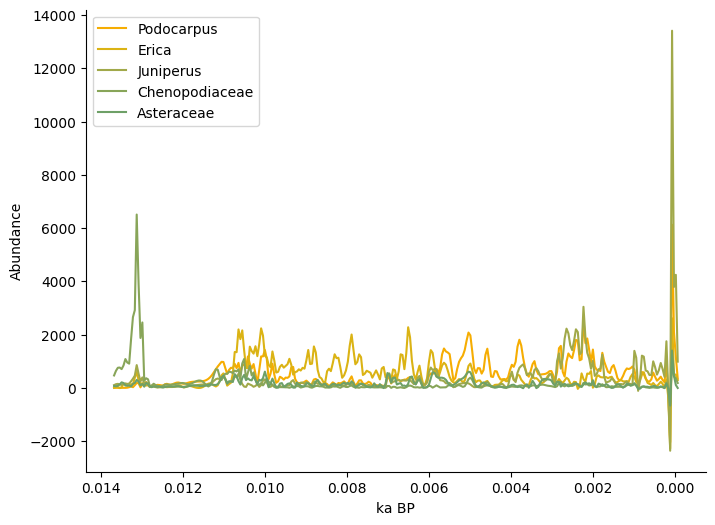

In [ ]:
import matplotlib.pyplot as plt
# plot varias especies
BSM_COLORS  = ["#9b2335", "#e8c4b8", "#d4843a", "#f6ad02"]
#encontar 10 especies más abundantes en df_bas
especies_plot=['Abies', 'Betula', 'Pinus', 'Quercus caducifolio']
especies_plot_abundantes = df_equidistante.sum().sort_values(ascending=False).index.tolist()
especies_plot = especies_plot_abundantes[1:6] 
plt.figure(figsize=(8, 6))
for sp in especies_plot:
    plt.plot(df_equidistante['cal BP']/1000, df_equidistante[sp], label=sp)
    #plt.scatter(df_mos['cal BP']/1000, df_mos[sp], s=10)
#eje x  de mayor a menor
plt.gca().invert_xaxis()
#sombrear ventanas
# plt.axvspan(6.253, 9.798, color=BSM_COLORS[0], alpha=0.1, label='')
# plt.axvspan(3.842, 6.182, color=BSM_COLORS[1], alpha=0.1, label='')
# plt.axvspan(-0.057, 3.771, color=BSM_COLORS[2], alpha=0.1, label='')
#plt.plot(df_equidistante['cal BP'], df_equidistante['Multiplier'], label='Multiplier', color='black', linestyle='--')
#quitar linea de la derecha y arriba
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.xlabel('ka BP')
#plt.ylim(0,100)
plt.ylabel('Abundance')
#plt.title('Evolución de las especies')
plt.legend()
plt.show()

# granger causality

In [ ]:
import numpy as np
import pandas as pd
import pickle
from statsmodels.tsa.api import VAR
import warnings

warnings.filterwarnings("ignore")

# =====================================================
# CONFIGURACIÓN
# =====================================================

N_BOOTSTRAP = 1000
MIN_PRESENCIA = 2.5
ALPHA = 0.05
MIN_VAR = 1e-10
ABUNDANCIA_MINIMA = 0

WINDOWS = {
    "w1": (7350, 6000),
    "w2": (6000, 3900),
    "w3": (3900, 1500),
    "w4": (1500, -57)
}
# =====================================================
# FUNCIONES
# =====================================================

def es_serie_valida(serie):
    serie = serie.where(serie >= ABUNDANCIA_MINIMA, 0)
    return (serie > 0).sum() >= MIN_PRESENCIA 

def bootstrap_estacionario(serie):
    n = len(serie)
    serie_period = np.concatenate((serie, serie))
    resultado = np.array([])

    while len(resultado) < n:
        L = int(np.random.exponential(scale=n))
        while L > n:
            L = int(np.random.exponential(scale=n))

        inicio = np.random.randint(0, n)
        restantes = n - len(resultado)
        L_actual = min(L, restantes)

        bloque = serie_period[inicio:inicio + L_actual]
        resultado = np.concatenate((resultado, bloque))

    return resultado

def generar_bootstrap_df(df, columnas):

    df_boot = pd.DataFrame()
    df_boot["cal BP"] = df["cal BP"].values
    df_boot["Multiplier"] = df["Multiplier"].values

    for col in columnas:
        df_boot[col] = bootstrap_estacionario(df[col].values)

    return df_boot

def extraer_ventana(df, cal_min, cal_max):
    mask = (df["cal BP"] >= min(cal_min, cal_max)) & \
           (df["cal BP"] <= max(cal_min, cal_max))
    return df[mask].copy().reset_index(drop=True)

def coef_sp1_a_sp2_condicional(df, sp1, sp2):

    try:
        x = df[sp1].values
        y = df[sp2].values
        mult = df["Multiplier"]

        if (np.std(x) < MIN_VAR or
            np.std(y) < MIN_VAR or
            np.std(mult) < MIN_VAR):
            return 0

        data = pd.DataFrame({
            sp1: x,
            sp2: y,
            "Mult": mult
        })

        model = VAR(data)
        results = model.fit(maxlags=1)

        return results.coefs[0][1][0]

    except:
        return 0


# =====================================================
# CARGAR DATOS
# =====================================================

with open("series_equidistantes_gam_mos_pc.pkl", "rb") as f:
    df_original = pickle.load(f)

df_original = df_original.sort_values("cal BP", ascending=False).reset_index(drop=True)

especies_cols = [c for c in df_original.columns if c not in ["cal BP", "Multiplier"]]
print("len", len(especies_cols))

np.random.seed(42)

# =====================================================
# ANÁLISIS
# =====================================================

for window_name, (cmin, cmax) in WINDOWS.items():

    print("\n" + "="*60)
    print("VENTANA:", window_name)
    print("="*60)

    df_w = extraer_ventana(df_original, cmin, cmax)
    print(f"Tamaño ventana: {len(df_w)} observaciones")

    especies_ventana = [
        sp for sp in especies_cols
        if es_serie_valida(df_w[sp])
    ]

    n_w = len(especies_ventana)
    print(f"Especies válidas en ventana: {n_w}")

    if n_w < 2:
        print("Muy pocas especies, se omite ventana")
        continue

    print("\nGenerando bootstrap...")
    boot_windows = [
        generar_bootstrap_df(df_w, especies_ventana)
        for _ in range(N_BOOTSTRAP)
    ]

    matriz_coef = np.full((n_w, n_w), np.nan)
    matriz_sig = np.zeros((n_w, n_w))
    matriz_pval = np.full((n_w, n_w), np.nan)

    valid_original = 0
    n_sig = 0
    n_low = 0
    n_high = 0

    # =====================================================
    # LOOP PARES
    # =====================================================

    total_pares = n_w * (n_w - 1)
    pares_procesados = 0
    siguiente_hito = 10

    for i, sp1 in enumerate(especies_ventana):
        for j, sp2 in enumerate(especies_ventana):

            if i == j:
                continue

            pares_procesados+=1
            porcentaje = pares_procesados * 100 / total_pares

            if porcentaje >= siguiente_hito:
                print(
                    f"Analizado {siguiente_hito}% "
                    f"de los pares ({pares_procesados}/{total_pares})"
                )
                siguiente_hito += 10


            coef_original = coef_sp1_a_sp2_condicional(df_w, sp1, sp2)

            if np.isnan(coef_original):
                continue

            valid_original += 1
            matriz_coef[i, j] = coef_original

            coefs_boot = []

            for df_b_w in boot_windows:
                coef_boot = coef_sp1_a_sp2_condicional(df_b_w, sp1, sp2)
                if not np.isnan(coef_boot):
                    coefs_boot.append(coef_boot)

            coefs_boot = np.array(coefs_boot)

            if len(coefs_boot) == 0:
                continue

            # cálculo p-value
            count = np.sum(np.abs(coefs_boot) >= np.abs(coef_original))
            p_value = count / len(coefs_boot)

            matriz_pval[i, j] = p_value

            if p_value < ALPHA:
                n_sig += 1
                if coef_original > 0:
                    matriz_sig[i, j] = 1
                    n_high += 1
                elif coef_original < 0:
                    matriz_sig[i, j] = -1
                    n_low += 1

    # =====================================================
    # DIAGNÓSTICO
    # =====================================================

    if valid_original > 0:
        print(f"Significativos: {n_sig} ({n_sig/valid_original*100:.2f}%)")

    if n_sig > 0:
        print(f"Cola baja: {n_low} ({n_low/n_sig*100:.2f}%)")
    print(f"Cola alta: {n_high}")

    # =====================================================
    # GUARDAR RESULTADOS
    # =====================================================

    resultado = {
        "especies": especies_ventana,
        "matriz_coeficientes": matriz_coef,
        "matriz_significancia": matriz_sig,
        "matriz_pvalores": matriz_pval
    }

    with open(f"mos_{window_name}_pc.pkl", "wb") as f:
        pickle.dump(resultado, f)


print("\nProceso terminado correctamente.")

len 91

VENTANA: w1
Tamaño ventana: 148 observaciones
Especies válidas en ventana: 64

Generando bootstrap...
Analizado 10% de los pares (404/4032)
Analizado 20% de los pares (807/4032)
Analizado 30% de los pares (1210/4032)
Analizado 40% de los pares (1613/4032)
Analizado 50% de los pares (2016/4032)
Analizado 60% de los pares (2420/4032)
Analizado 70% de los pares (2823/4032)
Analizado 80% de los pares (3226/4032)
Analizado 90% de los pares (3629/4032)
Analizado 100% de los pares (4032/4032)
Significativos: 192 (4.76%)
Cola baja: 45 (23.44%)
Cola alta: 147

Proceso terminado correctamente.


In [ ]:
import numpy as np
import pandas as pd
import pickle
from statsmodels.tsa.api import VAR
import warnings

warnings.filterwarnings("ignore")

# =====================================================
# CONFIGURACIÓN
# =====================================================

N_BOOTSTRAP = 300
MIN_PRESENCIA = 2.5
ALPHA = 0.05
MIN_VAR = 1e-10
ABUNDANCIA_MINIMA = 0.009

WINDOWS = {
    #"w1": (7350, 6000),
    "w2": (6000, 3900)
    #"w3": (3900, 1500),
    #"w4": (1500, -57)
}
# =====================================================
# FUNCIONES
# =====================================================

def es_serie_valida(serie):
    serie = serie.where(serie >= ABUNDANCIA_MINIMA, 0)
    return (serie > 0).sum() >= MIN_PRESENCIA 

def bootstrap_estacionario(serie):
    n = len(serie)
    serie_period = np.concatenate((serie, serie))
    resultado = np.array([])

    while len(resultado) < n:
        L = int(np.random.exponential(scale=n))
        while L > n:
            L = int(np.random.exponential(scale=n))

        inicio = np.random.randint(0, n)
        restantes = n - len(resultado)
        L_actual = min(L, restantes)

        bloque = serie_period[inicio:inicio + L_actual]
        resultado = np.concatenate((resultado, bloque))

    return resultado

def generar_bootstrap_df(df, columnas):

    df_boot = pd.DataFrame()
    df_boot["cal BP"] = df["cal BP"].values
    df_boot["Multiplier"] = df["Multiplier"].values

    for col in columnas:
        df_boot[col] = bootstrap_estacionario(df[col].values)

    return df_boot

def extraer_ventana(df, cal_min, cal_max):
    mask = (df["cal BP"] >= min(cal_min, cal_max)) & \
           (df["cal BP"] <= max(cal_min, cal_max))
    return df[mask].copy().reset_index(drop=True)

def coef_sp1_a_sp2_condicional(df, sp1, sp2):

    try:
        x = df[sp1].values
        y = df[sp2].values
        mult = df["Multiplier"]

        if (np.std(x) < MIN_VAR or
            np.std(y) < MIN_VAR or
            np.std(mult) < MIN_VAR):
            return 0

        data = pd.DataFrame({
            sp1: x,
            sp2: y,
            "Mult": mult
        })

        model = VAR(data)
        results = model.fit(maxlags=1)

        return results.coefs[0][1][0]

    except:
        return 0


# =====================================================
# CARGAR DATOS
# =====================================================

with open("series_equidistantes_gam_mos_pc.pkl", "rb") as f:
    df_original = pickle.load(f)

df_original = df_original.sort_values("cal BP", ascending=False).reset_index(drop=True)

especies_cols = [c for c in df_original.columns if c not in ["cal BP", "Multiplier"]]
print("len", len(especies_cols))

np.random.seed(42)

# =====================================================
# ANÁLISIS
# =====================================================

for window_name, (cmin, cmax) in WINDOWS.items():

    print("\n" + "="*60)
    print("VENTANA:", window_name)
    print("="*60)

    df_w = extraer_ventana(df_original, cmin, cmax)
    print(f"Tamaño ventana: {len(df_w)} observaciones")

    especies_ventana = [
        sp for sp in especies_cols
        if es_serie_valida(df_w[sp])
    ]

    n_w = len(especies_ventana)
    print(f"Especies válidas en ventana: {n_w}")

    if n_w < 2:
        print("Muy pocas especies, se omite ventana")
        continue

    print("\nGenerando bootstrap...")
    boot_windows = [
        generar_bootstrap_df(df_w, especies_ventana)
        for _ in range(N_BOOTSTRAP)
    ]

    matriz_coef = np.full((n_w, n_w), np.nan)
    matriz_sig = np.zeros((n_w, n_w))
    matriz_pval = np.full((n_w, n_w), np.nan)

    valid_original = 0
    n_sig = 0
    n_low = 0
    n_high = 0

    # =====================================================
    # LOOP PARES
    # =====================================================

    total_pares = n_w * (n_w - 1)
    pares_procesados = 0
    siguiente_hito = 10

    for i, sp1 in enumerate(especies_ventana):
        for j, sp2 in enumerate(especies_ventana):

            if i == j:
                continue

            pares_procesados+=1
            porcentaje = pares_procesados * 100 / total_pares

            if porcentaje >= siguiente_hito:
                print(
                    f"Analizado {siguiente_hito}% "
                    f"de los pares ({pares_procesados}/{total_pares})"
                )
                siguiente_hito += 10


            coef_original = coef_sp1_a_sp2_condicional(df_w, sp1, sp2)

            if np.isnan(coef_original):
                continue

            valid_original += 1
            matriz_coef[i, j] = coef_original

            coefs_boot = []

            for df_b_w in boot_windows:
                coef_boot = coef_sp1_a_sp2_condicional(df_b_w, sp1, sp2)
                if not np.isnan(coef_boot):
                    coefs_boot.append(coef_boot)

            coefs_boot = np.array(coefs_boot)

            if len(coefs_boot) == 0:
                continue

            # cálculo p-value
            count = np.sum(np.abs(coefs_boot) >= np.abs(coef_original))
            p_value = count / len(coefs_boot)

            matriz_pval[i, j] = p_value

            if p_value < ALPHA:
                n_sig += 1
                if coef_original > 0:
                    matriz_sig[i, j] = 1
                    n_high += 1
                elif coef_original < 0:
                    matriz_sig[i, j] = -1
                    n_low += 1

    # =====================================================
    # DIAGNÓSTICO
    # =====================================================

    if valid_original > 0:
        print(f"Significativos: {n_sig} ({n_sig/valid_original*100:.2f}%)")

    if n_sig > 0:
        print(f"Cola baja: {n_low} ({n_low/n_sig*100:.2f}%)")
    print(f"Cola alta: {n_high}")

    # =====================================================
    # GUARDAR RESULTADOS
    # =====================================================

    resultado = {
        "especies": especies_ventana,
        "matriz_coeficientes": matriz_coef,
        "matriz_significancia": matriz_sig,
        "matriz_pvalores": matriz_pval
    }

    with open(f"mos_{window_name}.pkl", "wb") as f:
        pickle.dump(resultado, f)


print("\nProceso terminado correctamente.")

len 91

VENTANA: w2
Tamaño ventana: 231 observaciones
Especies válidas en ventana: 70

Generando bootstrap...
Analizado 10% de los pares (483/4830)
Analizado 20% de los pares (966/4830)
Analizado 30% de los pares (1449/4830)
Analizado 40% de los pares (1932/4830)
Analizado 50% de los pares (2415/4830)
Analizado 60% de los pares (2898/4830)
Analizado 70% de los pares (3381/4830)
Analizado 80% de los pares (3864/4830)
Analizado 90% de los pares (4347/4830)
Analizado 100% de los pares (4830/4830)
Significativos: 317 (6.56%)
Cola baja: 77 (24.29%)
Cola alta: 240

Proceso terminado correctamente.


In [ ]:
import numpy as np
import pandas as pd
import pickle
from statsmodels.tsa.api import VAR
import warnings

warnings.filterwarnings("ignore")

# =====================================================
# CONFIGURACIÓN
# =====================================================

N_BOOTSTRAP = 300
MIN_PRESENCIA = 2.5
ALPHA = 0.05
MIN_VAR = 1e-10
ABUNDANCIA_MINIMA = 0.009

WINDOWS = {
    #"w1": (7350, 6000),
    #"w2": (6000, 3900)
    #"w3": (3900, 1500),
    "w4": (1500, -57)
}
# =====================================================
# FUNCIONES
# =====================================================

def es_serie_valida(serie):
    serie = serie.where(serie >= ABUNDANCIA_MINIMA, 0)
    return (serie > 0).sum() >= MIN_PRESENCIA 

def bootstrap_estacionario(serie):
    n = len(serie)
    serie_period = np.concatenate((serie, serie))
    resultado = np.array([])

    while len(resultado) < n:
        L = int(np.random.exponential(scale=n))
        while L > n:
            L = int(np.random.exponential(scale=n))

        inicio = np.random.randint(0, n)
        restantes = n - len(resultado)
        L_actual = min(L, restantes)

        bloque = serie_period[inicio:inicio + L_actual]
        resultado = np.concatenate((resultado, bloque))

    return resultado

def generar_bootstrap_df(df, columnas):

    df_boot = pd.DataFrame()
    df_boot["cal BP"] = df["cal BP"].values
    df_boot["Multiplier"] = df["Multiplier"].values

    for col in columnas:
        df_boot[col] = bootstrap_estacionario(df[col].values)

    return df_boot

def extraer_ventana(df, cal_min, cal_max):
    mask = (df["cal BP"] >= min(cal_min, cal_max)) & \
           (df["cal BP"] <= max(cal_min, cal_max))
    return df[mask].copy().reset_index(drop=True)

def coef_sp1_a_sp2_condicional(df, sp1, sp2):

    try:
        x = df[sp1].values
        y = df[sp2].values
        mult = df["Multiplier"]

        if (np.std(x) < MIN_VAR or
            np.std(y) < MIN_VAR or
            np.std(mult) < MIN_VAR):
            return 0

        data = pd.DataFrame({
            sp1: x,
            sp2: y,
            "Mult": mult
        })

        model = VAR(data)
        results = model.fit(maxlags=1)

        return results.coefs[0][1][0]

    except:
        return 0


# =====================================================
# CARGAR DATOS
# =====================================================

with open("series_equidistantes_gam_mos_pc.pkl", "rb") as f:
    df_original = pickle.load(f)

df_original = df_original.sort_values("cal BP", ascending=False).reset_index(drop=True)

especies_cols = [c for c in df_original.columns if c not in ["cal BP", "Multiplier"]]
print("len", len(especies_cols))

np.random.seed(42)

# =====================================================
# ANÁLISIS
# =====================================================

for window_name, (cmin, cmax) in WINDOWS.items():

    print("\n" + "="*60)
    print("VENTANA:", window_name)
    print("="*60)

    df_w = extraer_ventana(df_original, cmin, cmax)
    print(f"Tamaño ventana: {len(df_w)} observaciones")

    especies_ventana = [
        sp for sp in especies_cols
        if es_serie_valida(df_w[sp])
    ]

    n_w = len(especies_ventana)
    print(f"Especies válidas en ventana: {n_w}")

    if n_w < 2:
        print("Muy pocas especies, se omite ventana")
        continue

    print("\nGenerando bootstrap...")
    boot_windows = [
        generar_bootstrap_df(df_w, especies_ventana)
        for _ in range(N_BOOTSTRAP)
    ]

    matriz_coef = np.full((n_w, n_w), np.nan)
    matriz_sig = np.zeros((n_w, n_w))
    matriz_pval = np.full((n_w, n_w), np.nan)

    valid_original = 0
    n_sig = 0
    n_low = 0
    n_high = 0

    # =====================================================
    # LOOP PARES
    # =====================================================

    total_pares = n_w * (n_w - 1)
    pares_procesados = 0
    siguiente_hito = 10

    for i, sp1 in enumerate(especies_ventana):
        for j, sp2 in enumerate(especies_ventana):

            if i == j:
                continue

            pares_procesados+=1
            porcentaje = pares_procesados * 100 / total_pares

            if porcentaje >= siguiente_hito:
                print(
                    f"Analizado {siguiente_hito}% "
                    f"de los pares ({pares_procesados}/{total_pares})"
                )
                siguiente_hito += 10


            coef_original = coef_sp1_a_sp2_condicional(df_w, sp1, sp2)

            if np.isnan(coef_original):
                continue

            valid_original += 1
            matriz_coef[i, j] = coef_original

            coefs_boot = []

            for df_b_w in boot_windows:
                coef_boot = coef_sp1_a_sp2_condicional(df_b_w, sp1, sp2)
                if not np.isnan(coef_boot):
                    coefs_boot.append(coef_boot)

            coefs_boot = np.array(coefs_boot)

            if len(coefs_boot) == 0:
                continue

            # cálculo p-value
            count = np.sum(np.abs(coefs_boot) >= np.abs(coef_original))
            p_value = count / len(coefs_boot)

            matriz_pval[i, j] = p_value

            if p_value < ALPHA:
                n_sig += 1
                if coef_original > 0:
                    matriz_sig[i, j] = 1
                    n_high += 1
                elif coef_original < 0:
                    matriz_sig[i, j] = -1
                    n_low += 1

    # =====================================================
    # DIAGNÓSTICO
    # =====================================================

    if valid_original > 0:
        print(f"Significativos: {n_sig} ({n_sig/valid_original*100:.2f}%)")

    if n_sig > 0:
        print(f"Cola baja: {n_low} ({n_low/n_sig*100:.2f}%)")
    print(f"Cola alta: {n_high}")

    # =====================================================
    # GUARDAR RESULTADOS
    # =====================================================

    resultado = {
        "especies": especies_ventana,
        "matriz_coeficientes": matriz_coef,
        "matriz_significancia": matriz_sig,
        "matriz_pvalores": matriz_pval
    }

    with open(f"mos_{window_name}.pkl", "wb") as f:
        pickle.dump(resultado, f)


print("\nProceso terminado correctamente.")

len 91

VENTANA: w4
Tamaño ventana: 171 observaciones
Especies válidas en ventana: 79

Generando bootstrap...
Analizado 10% de los pares (617/6162)
Analizado 20% de los pares (1233/6162)
Analizado 30% de los pares (1849/6162)
Analizado 40% de los pares (2465/6162)
Analizado 50% de los pares (3081/6162)
Analizado 60% de los pares (3698/6162)
Analizado 70% de los pares (4314/6162)
Analizado 80% de los pares (4930/6162)
Analizado 90% de los pares (5546/6162)
Analizado 100% de los pares (6162/6162)
Significativos: 374 (6.07%)
Cola baja: 63 (16.84%)
Cola alta: 311

Proceso terminado correctamente.
